In [2]:
import json
import numpy as np
from PIL import Image
from pycocotools import mask as maskUtils
import os

# Define paths
json_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\train\_annotations.coco.json"
image_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\train"
mask_save_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked"

# Create the directory to save mask images if it doesn't exist
os.makedirs(mask_save_dir, exist_ok=True)

# Load the COCO JSON file
try:
    with open(json_path, 'r') as f:
        coco_data = json.load(f)
except FileNotFoundError:
    print(f"Error: JSON file not found at {json_path}")
    exit(1)

# Process each image in the JSON
for image_info in coco_data.get('images', []):
    # Get image details
    image_id = image_info['id']
    image_filename = image_info['file_name']
    image_width = image_info['width']
    image_height = image_info['height']

    # Full path to the image
    image_path = os.path.join(image_dir, image_filename)
    if not os.path.exists(image_path):
        print(f"Warning: Image {image_filename} not found in {image_dir}")
        continue

    # Create an empty mask image
    mask = np.zeros((image_height, image_width), dtype=np.uint8)

    # Find annotations corresponding to this image
    for annotation in coco_data.get('annotations', []):
        if annotation['image_id'] == image_id:
            # Get segmentation information (assumes polygons)
            segmentation = annotation.get('segmentation', [])
            
            try:
                # Handle polygon segmentation
                if isinstance(segmentation, list):
                    rle = maskUtils.frPyObjects(segmentation, image_height, image_width)
                    rle = maskUtils.merge(rle)  # Merge multiple parts
                    decoded_mask = maskUtils.decode(rle)

                    # Add the decoded mask (logical OR to combine masks)
                    mask = np.logical_or(mask, decoded_mask).astype(np.uint8)
                else:
                    print(f"Unexpected segmentation format for annotation ID {annotation['id']}. Skipping.")
            except Exception as e:
                print(f"Error processing annotation {annotation['id']}: {e}")
                continue

    # Scale the mask to 255 for visibility
    mask = mask * 255

    # Convert the mask to an image and save it
    mask_image = Image.fromarray(mask)
    mask_filename = os.path.splitext(image_filename)[0] + '_mask.png'
    mask_image.save(os.path.join(mask_save_dir, mask_filename))

    print(f"Saved mask for {image_filename} as {mask_filename}")


Saved mask for 8-169-_png.rf.1ae88933d03b08da3fb15037b52267c9.jpg as 8-169-_png.rf.1ae88933d03b08da3fb15037b52267c9_mask.png
Saved mask for 3-637-_png.rf.1a832893ef83c7ec294396a6b04c5b63.jpg as 3-637-_png.rf.1a832893ef83c7ec294396a6b04c5b63_mask.png
Saved mask for 3-237-_png.rf.1aa26691d5278d999eeb7c0447692e9e.jpg as 3-237-_png.rf.1aa26691d5278d999eeb7c0447692e9e_mask.png
Saved mask for 8-38-_png.rf.1c5622a6c39d14f18b0f63e97fb12747.jpg as 8-38-_png.rf.1c5622a6c39d14f18b0f63e97fb12747_mask.png
Saved mask for 3-610-_png.rf.1ad042df30b356a6f53b6a313520b705.jpg as 3-610-_png.rf.1ad042df30b356a6f53b6a313520b705_mask.png
Saved mask for 8-484-_png.rf.1bf4c8d5029c95d467cee87ae5777c57.jpg as 8-484-_png.rf.1bf4c8d5029c95d467cee87ae5777c57_mask.png
Saved mask for 8-36-_png.rf.1f2ff7f3d94c7e79fca0bc00e6571849.jpg as 8-36-_png.rf.1f2ff7f3d94c7e79fca0bc00e6571849_mask.png
Saved mask for 8-243-_png.rf.1fb4de2979615794f61e39033902bef3.jpg as 8-243-_png.rf.1fb4de2979615794f61e39033902bef3_mask.png
Save

C:\Users\kamal\anaconda3\envs\welding_xai\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\kamal\anaconda3\envs\welding_xai\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\kamal\AppData\Local\Temp\ipykernel_15772\393390254.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value

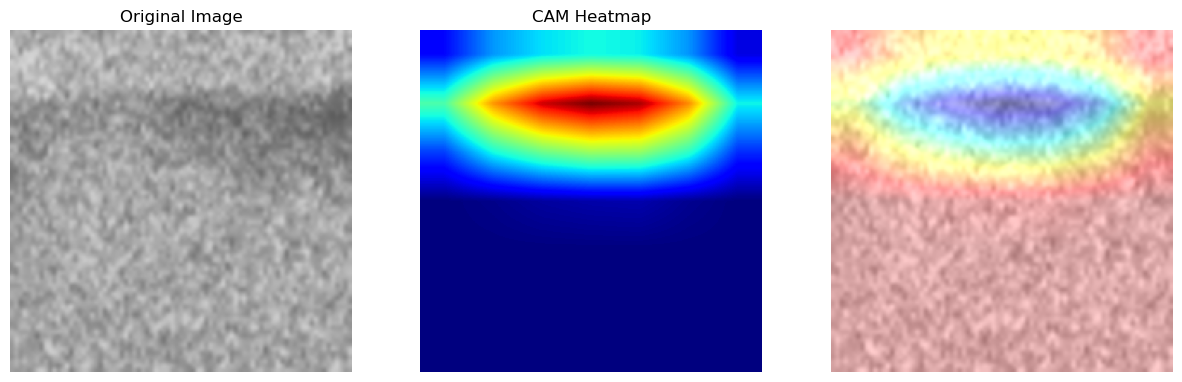

In [3]:
import torch
import torch.nn.functional as F
from torchvision.models import resnet18
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load the model
num_classes = 4
model = resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load('D:\\welding\\PAPER\\PAPER\\huge\\resnet18_fine_tune_all_best_model.pth', map_location=torch.device('cpu')))
model.eval()

# Load and preprocess the image
image_path = r"D:\welding\data\RIAWELC_dataset\DB - Copy\testing\Lp\RRT-26R_Img4_A80_S7_[10][19].png"
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_image = transform(image).unsqueeze(0)

# Register hooks to get activations and gradients
activations = []
gradients = []

def save_activations(module, input, output):
    activations.append(output)

def save_gradients(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Register hooks on the last convolutional block for ResNet-18
def get_last_conv_layer(model):
    for name, module in model.named_modules():
        if name == 'layer4':  # This is the last conv block in ResNet-18
            return module[-1]  # The last layer in layer4
    raise RuntimeError('Last convolutional layer not found')

last_conv_layer = get_last_conv_layer(model)
last_conv_layer.register_forward_hook(save_activations)
last_conv_layer.register_backward_hook(save_gradients)

# Forward pass
output = model(input_image)
predicted_class = output.argmax(dim=1)
output[0, predicted_class].backward()

# Compute Grad-CAM
activation = activations[0].cpu().data.numpy()[0]
gradients = gradients[0].cpu().data.numpy()[0]

# Pool the gradients across the channels
weights = np.mean(gradients, axis=(1, 2))
cam = np.zeros(activation.shape[1:], dtype=np.float32)
for i, w in enumerate(weights):
    cam += w * activation[i, :, :]

# Apply ReLU and normalize the CAM
cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224, 224))
cam = cam - np.min(cam)
cam = cam / np.max(cam)

# Prepare image for overlay
image_np = np.array(image.resize((224, 224)))
image_np = np.float32(image_np) / 255.0

# Generate heatmap and overlay
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255.0
superimposed_img = heatmap * 0.4 + image_np
# Convert the superimposed image from float32 back to uint8 format (0-255) for saving
# superimposed_img_uint8 = np.uint8(255 * superimposed_img)

# Save the overlay image
output_path = r"D:\welding\images\Supplimentary\gradcam\resnet18.png"
cv2.imwrite(output_path, superimposed_img * 255) 


# Plot results
plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image_np)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('CAM Heatmap')
plt.imshow(cam, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
# plt.title('resnet18')
plt.imshow(superimposed_img)
plt.axis('off')

plt.show()


In [4]:
import os
import torch
import torch.nn.functional as F
from torchvision.models import resnet18
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Paths
data_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\train"
output_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask"
os.makedirs(output_dir, exist_ok=True)

# Load the model
num_classes = 4
model = resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load(r'D:\welding\PAPER\PAPER\huge\resnet18_fine_tune_all_best_model.pth', map_location=torch.device('cpu')))
model.eval()

# Preprocessing transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Register hooks to get activations and gradients
activations = []
gradients = []

def save_activations(module, input, output):
    activations.append(output)

def save_gradients(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Get the last convolutional layer
def get_last_conv_layer(model):
    for name, module in model.named_modules():
        if name == 'layer4':  # This is the last conv block in ResNet-18
            return module[-1]
    raise RuntimeError('Last convolutional layer not found')

last_conv_layer = get_last_conv_layer(model)
last_conv_layer.register_forward_hook(save_activations)
last_conv_layer.register_backward_hook(save_gradients)

# Function to generate Grad-CAM and mask
def generate_gradcam_mask(image_path, output_path):
    global activations, gradients
    activations, gradients = [], []

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    input_image = transform(image).unsqueeze(0)

    # Forward pass
    output = model(input_image)
    predicted_class = output.argmax(dim=1)
    output[0, predicted_class].backward()

    # Compute Grad-CAM
    activation = activations[0].cpu().data.numpy()[0]
    gradients_ = gradients[0].cpu().data.numpy()[0]

    weights = np.mean(gradients_, axis=(1, 2))
    cam = np.zeros(activation.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * activation[i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = cam - np.min(cam)
    cam = cam / np.max(cam)

    # Prepare image for overlay
    image_np = np.array(image.resize((224, 224)))
    image_np = np.float32(image_np) / 255.0

    # Generate heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    superimposed_img = heatmap * 0.4 + image_np

    # Mask the region based on Grad-CAM
    cam_binary_mask = (cam > 0.5).astype(np.uint8)  # Threshold to create binary mask
    mask_applied_image = image_np * cam_binary_mask[:, :, None]

    # Save the masked image
    output_filename = os.path.basename(image_path)
    output_filepath = os.path.join(output_path, output_filename)
    cv2.imwrite(output_filepath, np.uint8(255 * mask_applied_image))

# Iterate through the dataset
for filename in os.listdir(data_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(data_dir, filename)
        generate_gradcam_mask(image_path, output_dir)
        print(f"Processed and saved Grad-CAM mask for {filename}")


C:\Users\kamal\AppData\Local\Temp\ipykernel_15772\287301967.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r'D:\welding\PAPER\PAPER\hu

Processed and saved Grad-CAM mask for 3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg
Processed and saved Grad-CAM mask for 3-10-_png.rf.dac42522617fb5b4d8698332965bd375.jpg
Processed and saved Grad-CAM mask for 3-101-_png.rf.c84e23fe771cf1cc8803958b52708f6c.jpg
Processed and saved Grad-CAM mask for 3-102-_png.rf.11be65e9868125a42bd9786a7944ad97.jpg
Processed and saved Grad-CAM mask for 3-103-_png.rf.425045e1a4967204a4c80fe390205109.jpg
Processed and saved Grad-CAM mask for 3-105-_png.rf.2cf37fae4c34aaa5d434427a494eb613.jpg
Processed and saved Grad-CAM mask for 3-106-_png.rf.1e38ee04220711ed993345dd61e1112e.jpg
Processed and saved Grad-CAM mask for 3-107-_png.rf.909e7014928fbbe5b0cfc19f3b74802f.jpg
Processed and saved Grad-CAM mask for 3-108-_png.rf.3adc2ac8dc7ac7eb0fb894bba02d507d.jpg
Processed and saved Grad-CAM mask for 3-109-_png.rf.e594b1b921e4eebf162a3d7d682451cd.jpg
Processed and saved Grad-CAM mask for 3-11-_png.rf.83591b92c004d872e17f29efb69b123a.jpg
Processed and saved Grad-

In [9]:
import os
import cv2
import numpy as np
from sklearn.metrics import jaccard_score, f1_score

# Directories
gradcam_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask"
expert_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked"
output_metrics = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\metrics.csv"

# Target size for resizing
target_size = (224, 224)

# Function to calculate evaluation metrics
def calculate_metrics(gradcam_mask, expert_mask):
    # Flatten masks for metrics calculation
    gradcam_mask = gradcam_mask.flatten()
    expert_mask = expert_mask.flatten()
    
    # Ensure binary masks
    gradcam_mask = (gradcam_mask > 0).astype(np.uint8)
    expert_mask = (expert_mask > 0).astype(np.uint8)
    
    # Jaccard Index (IoU) and F1 Score (Dice Coefficient)
    iou = jaccard_score(expert_mask, gradcam_mask, average='binary')
    f1 = f1_score(expert_mask, gradcam_mask, average='binary')
    
    return iou, f1

# Ensure results list
results = []

# Process files
gradcam_files = os.listdir(gradcam_dir)

for gradcam_file in gradcam_files:
    gradcam_path = os.path.join(gradcam_dir, gradcam_file)
    gradcam_basename = os.path.splitext(gradcam_file)[0]  # Filename without extension
    
    # Construct expert mask filename
    expert_file = f"{gradcam_basename}_mask.png"
    expert_path = os.path.join(expert_dir, expert_file)
    
    if os.path.exists(expert_path):
        # Read masks
        gradcam_mask = cv2.imread(gradcam_path, cv2.IMREAD_GRAYSCALE)
        expert_mask = cv2.imread(expert_path, cv2.IMREAD_GRAYSCALE)
        
        if gradcam_mask is not None and expert_mask is not None:
            # Resize masks to the same size
            gradcam_mask_resized = cv2.resize(gradcam_mask, target_size, interpolation=cv2.INTER_NEAREST)
            expert_mask_resized = cv2.resize(expert_mask, target_size, interpolation=cv2.INTER_NEAREST)
            
            # Calculate metrics
            iou, f1 = calculate_metrics(gradcam_mask_resized, expert_mask_resized)
            results.append((gradcam_file, iou, f1))
            print(f"Processed {gradcam_file}: IoU={iou:.4f}, F1={f1:.4f}")
        else:
            print(f"Error reading masks for {gradcam_file}. Skipping!")
    else:
        print(f"Expert mask for {gradcam_file} not found. Skipping!")

# Save results to CSV
with open(output_metrics, 'w') as f:
    f.write('Filename,IoU,F1\n')
    for result in results:
        f.write(f"{result[0]},{result[1]:.4f},{result[2]:.4f}\n")

print(f"Metrics saved to {output_metrics}")


Processed 3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg: IoU=0.0900, F1=0.1651
Processed 3-10-_png.rf.dac42522617fb5b4d8698332965bd375.jpg: IoU=0.2764, F1=0.4331
Processed 3-101-_png.rf.c84e23fe771cf1cc8803958b52708f6c.jpg: IoU=0.1877, F1=0.3161
Processed 3-102-_png.rf.11be65e9868125a42bd9786a7944ad97.jpg: IoU=0.2021, F1=0.3362
Processed 3-103-_png.rf.425045e1a4967204a4c80fe390205109.jpg: IoU=0.1433, F1=0.2506
Processed 3-105-_png.rf.2cf37fae4c34aaa5d434427a494eb613.jpg: IoU=0.2144, F1=0.3531
Processed 3-106-_png.rf.1e38ee04220711ed993345dd61e1112e.jpg: IoU=0.1112, F1=0.2002
Processed 3-107-_png.rf.909e7014928fbbe5b0cfc19f3b74802f.jpg: IoU=0.0266, F1=0.0519
Processed 3-108-_png.rf.3adc2ac8dc7ac7eb0fb894bba02d507d.jpg: IoU=0.4165, F1=0.5881
Processed 3-109-_png.rf.e594b1b921e4eebf162a3d7d682451cd.jpg: IoU=0.1409, F1=0.2470
Processed 3-11-_png.rf.83591b92c004d872e17f29efb69b123a.jpg: IoU=0.0959, F1=0.1750
Processed 3-110-_png.rf.e73309b5ea22b7c858ac422736d6e0af.jpg: IoU=0.1707, F1=0.2

In [11]:
import os
import cv2
import numpy as np
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, f1_score

# Directories
gradcam_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask"
expert_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked"
output_metrics = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\ecs_metrics.csv"

# Target size for resizing
target_size = (224, 224)

# Function to calculate ECS metrics
def calculate_ecs(gradcam_mask, expert_mask, threshold=0.5):
    # Binarize Grad-CAM mask
    gradcam_binary = (gradcam_mask >= threshold).astype(int)
    
    # Ensure expert mask is binary
    expert_binary = (expert_mask > 0).astype(int)
    
    # Flatten the masks for pixel-wise comparison
    gradcam_flat = gradcam_binary.flatten()
    expert_flat = expert_binary.flatten()
    
    # Metrics calculations
    kappa = cohen_kappa_score(expert_flat, gradcam_flat)
    precision = precision_score(expert_flat, gradcam_flat, average='binary', zero_division=0)
    recall = recall_score(expert_flat, gradcam_flat, average='binary', zero_division=0)
    f1 = f1_score(expert_flat, gradcam_flat, average='binary', zero_division=0)
    
    # ECS computation (example weighting: 0.5 Kappa, 0.5 F1)
    ecs = 0.5 * kappa + 0.5 * f1
    
    return {
        "kappa": kappa,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "ecs": ecs
    }

# Ensure results list
results = []

# Process files
gradcam_files = os.listdir(gradcam_dir)

for gradcam_file in gradcam_files:
    gradcam_path = os.path.join(gradcam_dir, gradcam_file)
    gradcam_basename = os.path.splitext(gradcam_file)[0]  # Filename without extension
    
    # Construct expert mask filename
    expert_file = f"{gradcam_basename}_mask.png"
    expert_path = os.path.join(expert_dir, expert_file)
    
    if os.path.exists(expert_path):
        # Read masks
        gradcam_mask = cv2.imread(gradcam_path, cv2.IMREAD_GRAYSCALE)
        expert_mask = cv2.imread(expert_path, cv2.IMREAD_GRAYSCALE)
        
        if gradcam_mask is not None and expert_mask is not None:
            # Resize masks to the same size
            gradcam_mask_resized = cv2.resize(gradcam_mask, target_size, interpolation=cv2.INTER_NEAREST)
            expert_mask_resized = cv2.resize(expert_mask, target_size, interpolation=cv2.INTER_NEAREST)
            
            # Calculate ECS metrics
            metrics = calculate_ecs(gradcam_mask_resized, expert_mask_resized)
            results.append((gradcam_file, metrics["kappa"], metrics["precision"], metrics["recall"], metrics["f1_score"], metrics["ecs"]))
            print(f"Processed {gradcam_file}: ECS={metrics['ecs']:.4f}, Kappa={metrics['kappa']:.4f}, F1={metrics['f1_score']:.4f}")
        else:
            print(f"Error reading masks for {gradcam_file}. Skipping!")
    else:
        print(f"Expert mask for {gradcam_file} not found. Skipping!")

# Save results to CSV
with open(output_metrics, 'w') as f:
    f.write('Filename,Kappa,Precision,Recall,F1_Score,ECS\n')
    for result in results:
        f.write(f"{result[0]},{result[1]:.4f},{result[2]:.4f},{result[3]:.4f},{result[4]:.4f},{result[5]:.4f}\n")

print(f"Metrics saved to {output_metrics}")


Processed 3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg: ECS=0.1544, Kappa=0.1438, F1=0.1651
Processed 3-10-_png.rf.dac42522617fb5b4d8698332965bd375.jpg: ECS=0.3892, Kappa=0.3454, F1=0.4331
Processed 3-101-_png.rf.c84e23fe771cf1cc8803958b52708f6c.jpg: ECS=0.2347, Kappa=0.1533, F1=0.3161
Processed 3-102-_png.rf.11be65e9868125a42bd9786a7944ad97.jpg: ECS=0.2959, Kappa=0.2555, F1=0.3362
Processed 3-103-_png.rf.425045e1a4967204a4c80fe390205109.jpg: ECS=0.1952, Kappa=0.1397, F1=0.2506
Processed 3-105-_png.rf.2cf37fae4c34aaa5d434427a494eb613.jpg: ECS=0.3110, Kappa=0.2690, F1=0.3531
Processed 3-106-_png.rf.1e38ee04220711ed993345dd61e1112e.jpg: ECS=0.1702, Kappa=0.1403, F1=0.2002
Processed 3-107-_png.rf.909e7014928fbbe5b0cfc19f3b74802f.jpg: ECS=0.0450, Kappa=0.0380, F1=0.0519
Processed 3-108-_png.rf.3adc2ac8dc7ac7eb0fb894bba02d507d.jpg: ECS=0.5435, Kappa=0.4989, F1=0.5881
Processed 3-109-_png.rf.e594b1b921e4eebf162a3d7d682451cd.jpg: ECS=0.1963, Kappa=0.1455, F1=0.2470
Processed 3-11-_png.rf.

In [12]:
import pandas as pd

# Load CSV files
ecs_metrics_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\ecs_metrics.csv"
metrics_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\metrics.csv"

ecs_df = pd.read_csv(ecs_metrics_path)
metrics_df = pd.read_csv(metrics_path)

# Display summary statistics
print("ECS Metrics Summary:")
print(ecs_df.describe())

print("\nOther Metrics Summary:")
print(metrics_df.describe())


ECS Metrics Summary:
             Kappa    Precision       Recall     F1_Score          ECS
count  1016.000000  1016.000000  1016.000000  1016.000000  1016.000000
mean      0.332694     0.311845     0.770141     0.400997     0.366846
std       0.177312     0.189117     0.245563     0.181582     0.178481
min      -0.177400     0.000000     0.000000     0.000000    -0.088700
25%       0.200650     0.164450     0.645875     0.260550     0.231225
50%       0.321050     0.275150     0.846350     0.396450     0.357750
75%       0.465825     0.442875     0.986425     0.546925     0.502550
max       0.773900     0.884700     1.000000     0.816200     0.795000

Other Metrics Summary:
               IoU           F1
count  1016.000000  1016.000000
mean      0.267369     0.400997
std       0.147341     0.181582
min       0.000000     0.000000
25%       0.149775     0.260550
50%       0.247200     0.396450
75%       0.376425     0.546925
max       0.689400     0.816200


In [13]:
ecs_df

,Filename,Kappa,Precision,Recall,F1_Score,ECS
0,3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg,0.1438,0.0912,0.8696,0.1651,0.1544
1,3-10-_png.rf.dac42522617fb5b4d8698332965bd375.jpg,0.3454,0.3356,0.6104,0.4331,0.3892
2,3-101-_png.rf.c84e23fe771cf1cc8803958b52708f6c...,0.1533,0.3041,0.3291,0.3161,0.2347
3,3-102-_png.rf.11be65e9868125a42bd9786a7944ad97...,0.2555,0.2792,0.4224,0.3362,0.2959
4,3-103-_png.rf.425045e1a4967204a4c80fe390205109...,0.1397,0.1762,0.4343,0.2506,0.1952
...,...,...,...,...,...,...
1011,RRT-90R_Img3_A80_S5_-4-36-_png.rf.c371c99c85dc...,0.2754,0.1912,0.9877,0.3204,0.2979
1012,RRT-90R_Img4_A80_S1_-5-18-_png.rf.57496b0dbb78...,-0.0281,0.0000,0.0000,0.0000,-0.0141
1013,RRT-90R_Img4_A80_S3_-3-25-_png.rf.e343435e2df4...,0.2689,0.1763,0.8796,0.2937,0.2813
1014,RRT-90R_Img4_A80_S5_-3-38-_png.rf.ccf496307a03...,0.4809,0.3565,0.9086,0.5121,0.4965


In [14]:
metrics_df

,Filename,IoU,F1
0,3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg,0.0900,0.1651
1,3-10-_png.rf.dac42522617fb5b4d8698332965bd375.jpg,0.2764,0.4331
2,3-101-_png.rf.c84e23fe771cf1cc8803958b52708f6c...,0.1877,0.3161
3,3-102-_png.rf.11be65e9868125a42bd9786a7944ad97...,0.2021,0.3362
4,3-103-_png.rf.425045e1a4967204a4c80fe390205109...,0.1433,0.2506
...,...,...,...
1011,RRT-90R_Img3_A80_S5_-4-36-_png.rf.c371c99c85dc...,0.1908,0.3204
1012,RRT-90R_Img4_A80_S1_-5-18-_png.rf.57496b0dbb78...,0.0000,0.0000
1013,RRT-90R_Img4_A80_S3_-3-25-_png.rf.e343435e2df4...,0.1721,0.2937
1014,RRT-90R_Img4_A80_S5_-3-38-_png.rf.ccf496307a03...,0.3442,0.5121


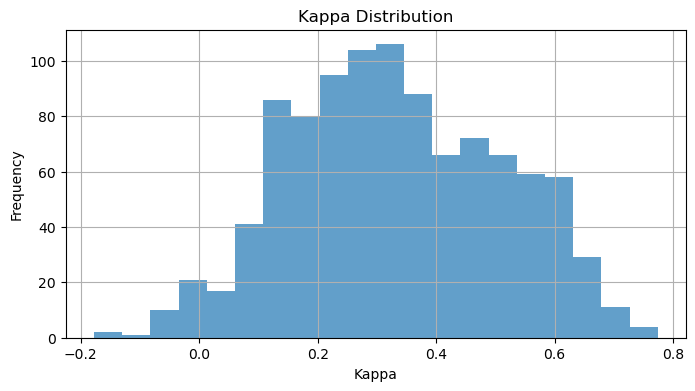

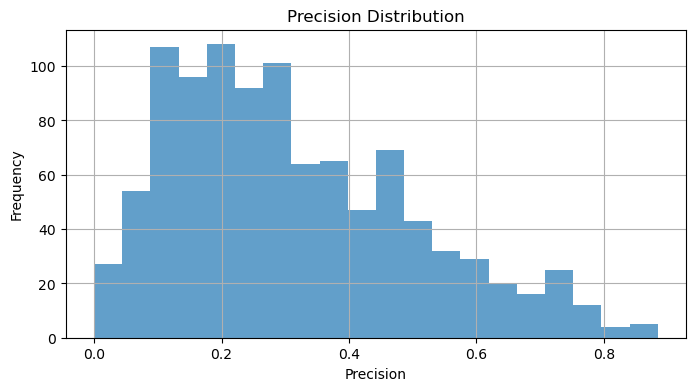

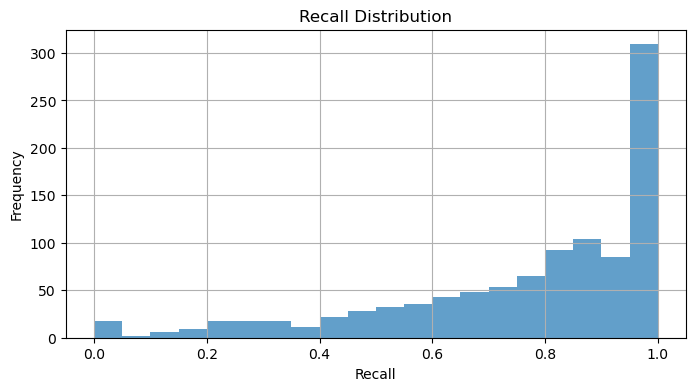

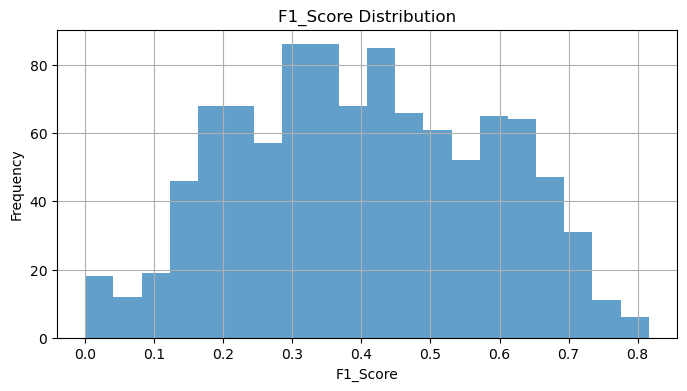

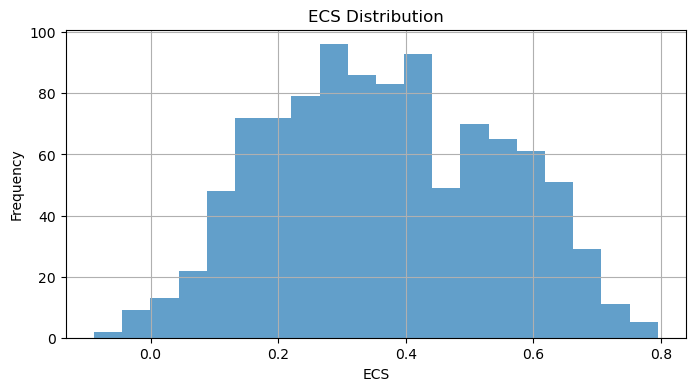

In [24]:
import matplotlib.pyplot as plt

# Plot histograms for metrics
metrics = ["Kappa", "Precision", "Recall", "F1_Score", "ECS"]
for metric in metrics:
    plt.figure(figsize=(8, 4))
    plt.hist(ecs_df[metric], bins=20, alpha=0.7)
    plt.title(f'{metric} Distribution')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


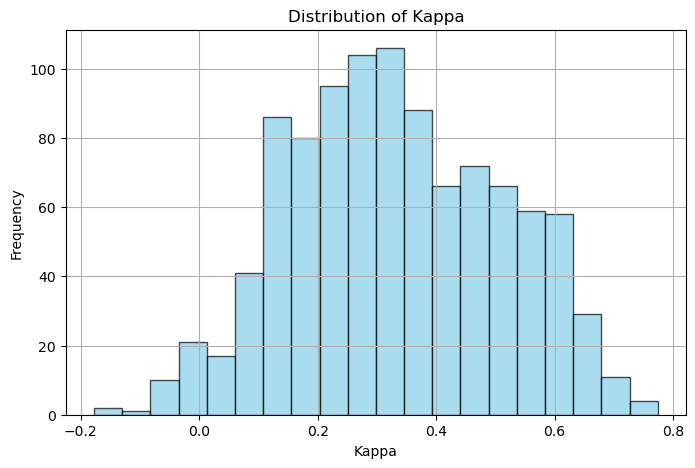

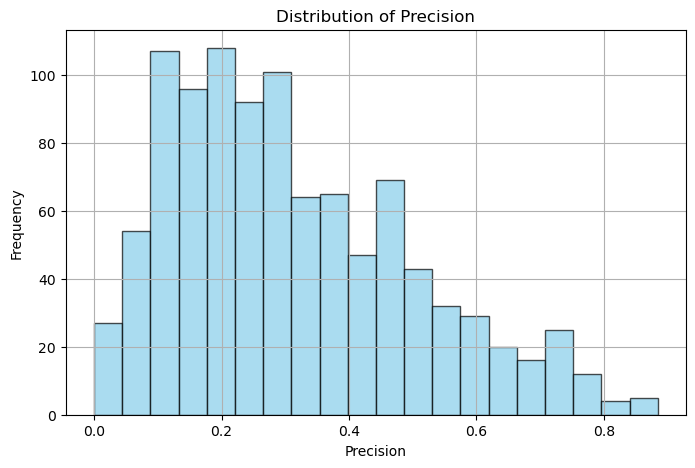

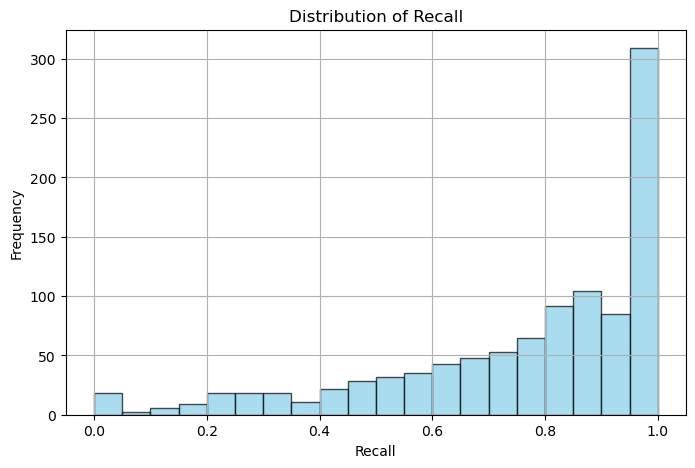

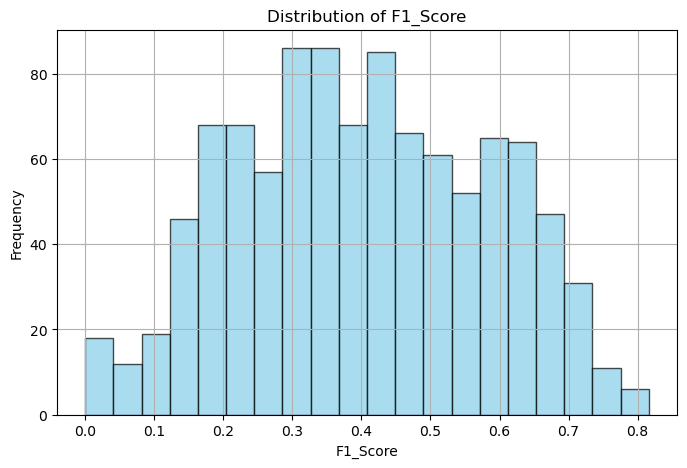

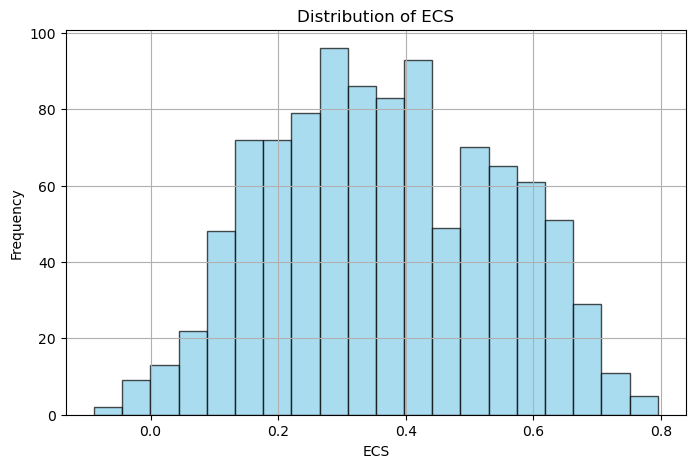

In [15]:
import matplotlib.pyplot as plt

metrics = ['Kappa', 'Precision', 'Recall', 'F1_Score', 'ECS']

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.hist(ecs_df[metric], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {metric}')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()


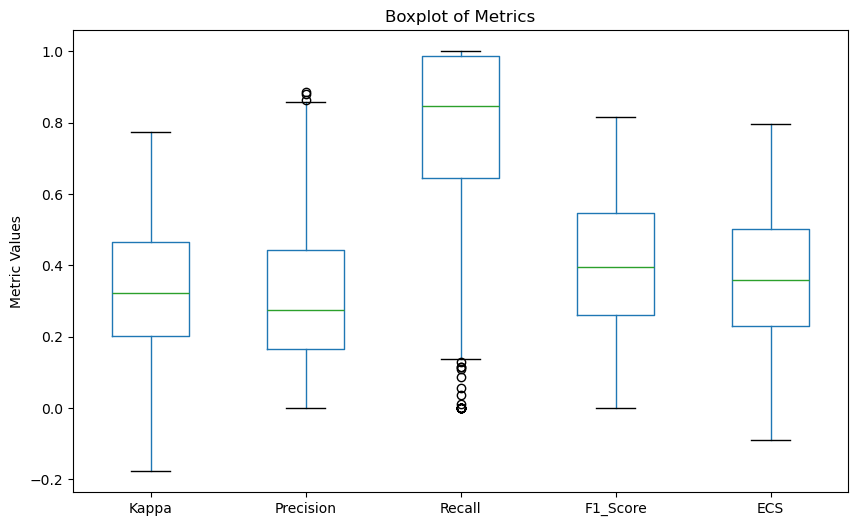

In [16]:
plt.figure(figsize=(10, 6))
ecs_df.boxplot(column=['Kappa', 'Precision', 'Recall', 'F1_Score', 'ECS'])
plt.title('Boxplot of Metrics')
plt.ylabel('Metric Values')
plt.grid()
plt.show()


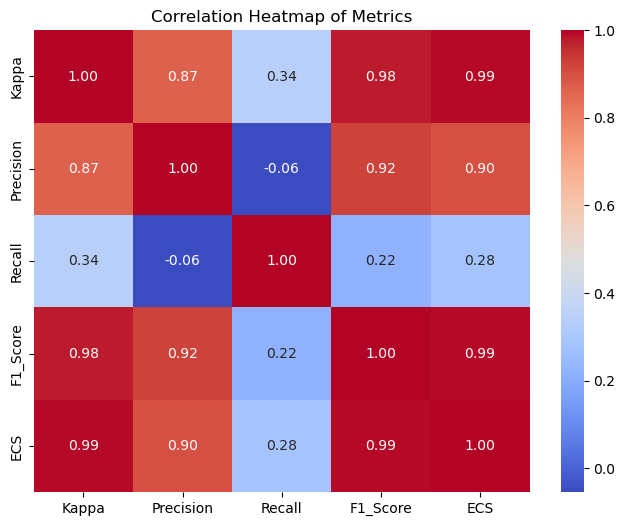

In [17]:
import seaborn as sns

plt.figure(figsize=(8, 6))
correlation_matrix = ecs_df[['Kappa', 'Precision', 'Recall', 'F1_Score', 'ECS']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Metrics')
plt.show()


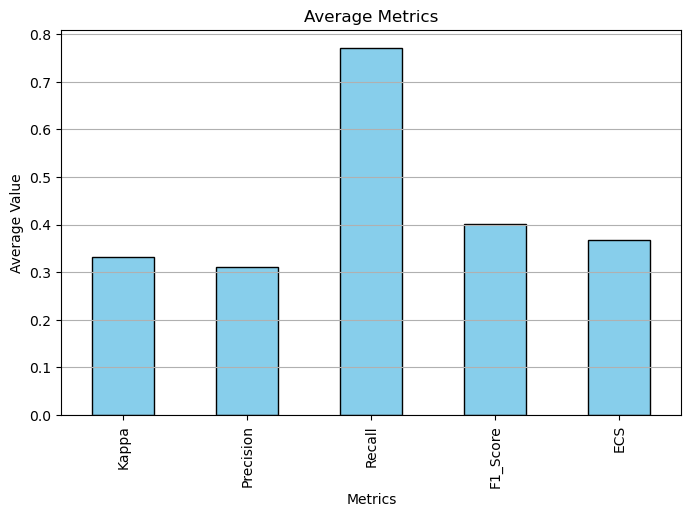

In [18]:
avg_metrics = ecs_df[['Kappa', 'Precision', 'Recall', 'F1_Score', 'ECS']].mean()

plt.figure(figsize=(8, 5))
avg_metrics.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Metrics')
plt.ylabel('Average Value')
plt.xlabel('Metrics')
plt.grid(axis='y')
plt.show()


In [19]:
top_images = ecs_df.nlargest(5, 'ECS')
bottom_images = ecs_df.nsmallest(5, 'ECS')

print("Top 5 Images Based on ECS:")
print(top_images)

print("\nBottom 5 Images Based on ECS:")
print(bottom_images)


Top 5 Images Based on ECS:
                                              Filename   Kappa  Precision  \
814  RRT-24R_Img2_A80_S4_-7-36-_png.rf.90912028d835...  0.7739     0.7124   
899  RRT-27R_Img2_A80_S5_-4-17-_png.rf.615fc46dc4ad...  0.7450     0.7688   
907  RRT-27R_Img3_A80_S6_-5-4-_png.rf.678502d35bfdf...  0.7406     0.7405   
831  RRT-26R_Img2_A80_S1_-13-42-_png.rf.6901b5a2637...  0.7221     0.8812   
357  8-198-_png.rf.ceb9d72b6a38deacdb5f967bcdae80b4...  0.7320     0.6510   

     Recall  F1_Score     ECS  
814  0.9554    0.8162  0.7950  
899  0.8130    0.7903  0.7676  
907  0.8379    0.7862  0.7634  
831  0.7209    0.7931  0.7576  
357  0.9742    0.7804  0.7562  

Bottom 5 Images Based on ECS:
                                              Filename   Kappa  Precision  \
32   3-142-_png.rf.0a3364411e9c3affd150e6862a489fb5... -0.1774     0.0000   
653  8-574-_png.rf.2cd05960d014436a29aa4e153d4d1d02... -0.1468     0.0235   
718  bam5_Img1_A80_S2_-4-21-_png.rf.c68cdc6df54da34... -

In [21]:
top_images

,Filename,Kappa,Precision,Recall,F1_Score,ECS
814,RRT-24R_Img2_A80_S4_-7-36-_png.rf.90912028d835...,0.7739,0.7124,0.9554,0.8162,0.7950
899,RRT-27R_Img2_A80_S5_-4-17-_png.rf.615fc46dc4ad...,0.7450,0.7688,0.8130,0.7903,0.7676
907,RRT-27R_Img3_A80_S6_-5-4-_png.rf.678502d35bfdf...,0.7406,0.7405,0.8379,0.7862,0.7634
831,RRT-26R_Img2_A80_S1_-13-42-_png.rf.6901b5a2637...,0.7221,0.8812,0.7209,0.7931,0.7576
357,8-198-_png.rf.ceb9d72b6a38deacdb5f967bcdae80b4...,0.7320,0.6510,0.9742,0.7804,0.7562


In [22]:
bottom_images

,Filename,Kappa,Precision,Recall,F1_Score,ECS
32,3-142-_png.rf.0a3364411e9c3affd150e6862a489fb5...,-0.1774,0.0000,0.0000,0.0000,-0.0887
653,8-574-_png.rf.2cd05960d014436a29aa4e153d4d1d02...,-0.1468,0.0235,0.0124,0.0162,-0.0653
718,bam5_Img1_A80_S2_-4-21-_png.rf.c68cdc6df54da34...,-0.0798,0.0000,0.0000,0.0000,-0.0399
719,bam5_Img1_A80_S2_-5-18-_png.rf.de67acfc53edd4b...,-0.0713,0.0000,0.0000,0.0000,-0.0356
410,8-263-_png.rf.879202380bd0e7e0f61a1ae7091d7d22...,-0.1205,0.0563,0.0556,0.0559,-0.0323


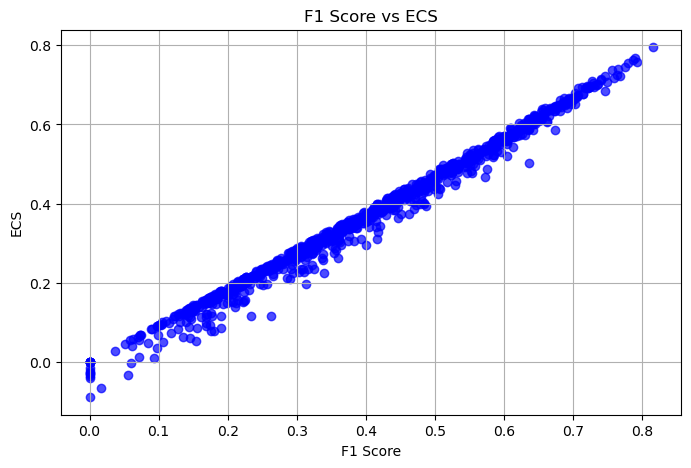

In [20]:
# Scatter plot of F1 Score vs ECS
plt.figure(figsize=(8, 5))
plt.scatter(ecs_df['F1_Score'], ecs_df['ECS'], alpha=0.7, color='blue')
plt.title('F1 Score vs ECS')
plt.xlabel('F1 Score')
plt.ylabel('ECS')
plt.grid()
plt.show()


In [30]:
import numpy as np
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, f1_score
from PIL import Image

# Function to calculate IoU (Intersection over Union)
def calculate_iou(gradcam_mask, expert_mask, threshold=0.5):
    gradcam_binary = (gradcam_mask >= threshold).astype(int)
    expert_binary = expert_mask.astype(int)
    
    intersection = np.sum(np.logical_and(gradcam_binary, expert_binary))
    union = np.sum(np.logical_or(gradcam_binary, expert_binary))
    
    return intersection / union if union != 0 else 0

# Function to calculate Dice Score
def calculate_dice(gradcam_mask, expert_mask, threshold=0.5):
    gradcam_binary = (gradcam_mask >= threshold).astype(int)
    expert_binary = expert_mask.astype(int)
    
    intersection = np.sum(np.logical_and(gradcam_binary, expert_binary))
    return 2 * intersection / (np.sum(gradcam_binary) + np.sum(expert_binary))

# Load the Grad-CAM mask and Expert mask from file paths
def load_image(image_path, target_size=None):
    # Load image using PIL and convert to grayscale (if needed)
    image = Image.open(image_path).convert('L')  # Convert to grayscale
    if target_size:
        image = image.resize(target_size)  # Resize image to target size
    return np.array(image)

# Example Usage
gradcam_image_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg"  # Path to Grad-CAM mask
expert_image_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png"  # Path to Expert mask

# Load images
gradcam_mask = load_image(gradcam_image_path)
expert_mask = load_image(expert_image_path)

# Resize the expert mask to match Grad-CAM mask size (224x224)
expert_mask_resized = Image.fromarray(expert_mask).resize(gradcam_mask.shape[::-1])  # Resize to match Grad-CAM
expert_mask_resized = np.array(expert_mask_resized)

# Binarize Grad-CAM mask at a threshold
threshold = 0.5
gradcam_binary = (gradcam_mask >= threshold).astype(int)

# Flatten both masks for comparison
gradcam_flat = gradcam_binary.flatten()
expert_flat = expert_mask_resized.flatten()

# Cohen's Kappa
kappa = cohen_kappa_score(expert_flat, gradcam_flat)

# Precision, Recall, F1-Score (Use macro average for multiclass classification)
precision = precision_score(expert_flat, gradcam_flat, average='macro')  # Use 'macro' for multiclass
recall = recall_score(expert_flat, gradcam_flat, average='macro')  # Use 'macro' for multiclass
f1 = f1_score(expert_flat, gradcam_flat, average='macro')  # Use 'macro' for multiclass

# ECS (combination of Kappa and F1)
ecs = 0.5 * kappa + 0.5 * f1

# Dice Score
dice_score = calculate_dice(gradcam_mask, expert_mask_resized, threshold)

# IoU
iou = calculate_iou(gradcam_mask, expert_mask_resized, threshold)

# Print Results for the example image
print("Results for the image:")
print(f"Kappa: {kappa:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ECS: {ecs:.4f}")
print(f"Dice Score: {dice_score:.4f}")
print(f"IoU: {iou:.4f}")


Results for the image:
Kappa: 0.0828
Precision: 0.0062
Recall: 0.0117
F1-Score: 0.0058
ECS: 0.0443
Dice Score: 0.0078
IoU: 0.1065


C:\Users\kamal\anaconda3\envs\welding_xai\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Masks have different sizes. Resizing the cam_mask to match real_mask.
IoU Score: 0.0000
Dice Coefficient: 0.0000


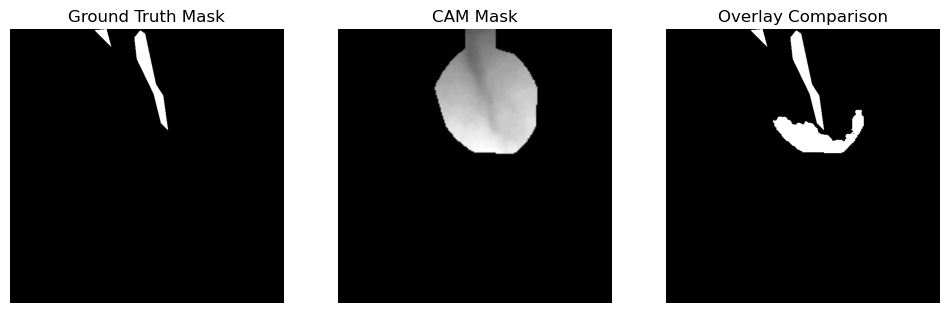

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the masks (update with the new paths)
cam_mask_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg"
real_mask_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png"

cam_mask = cv2.imread(cam_mask_path, cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(real_mask_path, cv2.IMREAD_GRAYSCALE)

# Ensure both masks are the same size
if cam_mask.shape != real_mask.shape:
    print("Masks have different sizes. Resizing the cam_mask to match real_mask.")
    cam_mask = cv2.resize(cam_mask, (real_mask.shape[1], real_mask.shape[0]))

# Convert masks to binary
_, cam_mask_bin = cv2.threshold(cam_mask, 127, 1, cv2.THRESH_BINARY)
_, real_mask_bin = cv2.threshold(real_mask, 127, 1, cv2.THRESH_BINARY)

# Compute Intersection over Union (IoU)
intersection = np.logical_and(real_mask_bin, cam_mask_bin)
union = np.logical_or(real_mask_bin, cam_mask_bin)
iou_score = np.sum(intersection) / np.sum(union)

# Compute Dice Coefficient
dice_score = 2 * np.sum(intersection) / (np.sum(real_mask_bin) + np.sum(cam_mask_bin))

# Print metrics
print(f"IoU Score: {iou_score:.4f}")
print(f"Dice Coefficient: {dice_score:.4f}")

# Plot masks for visual comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(real_mask, cmap='gray')
plt.title('Ground Truth Mask')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam_mask, cmap='gray')
plt.title('CAM Mask')
plt.axis('off')

# Overlay comparison
overlay = np.where(cam_mask_bin > 0, 255, 0).astype(np.uint8)
overlay = cv2.addWeighted(real_mask, 0.5, overlay, 0.5, 0)

plt.subplot(1, 3, 3)
plt.imshow(overlay, cmap='gray')
plt.title('Overlay Comparison')
plt.axis('off')

plt.show()


Masks have different sizes. Resizing the cam_mask to match real_mask.
Containment (Ground Truth in Grad-CAM): Not 100%
IoU Score: 0.0000
Dice Coefficient: 0.0000


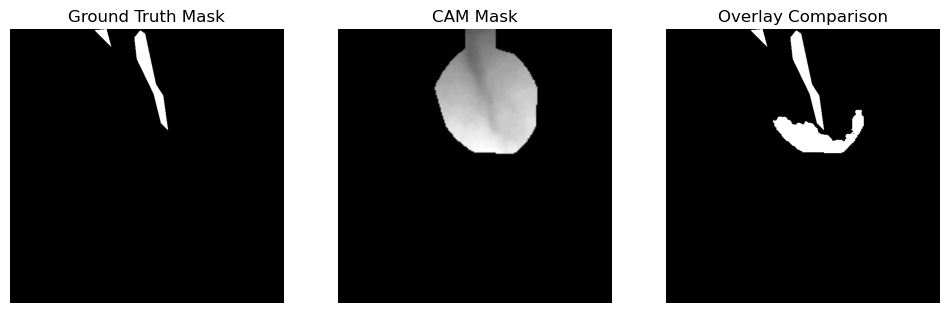

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the masks (update with the new paths)
cam_mask_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg"
real_mask_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png"

cam_mask = cv2.imread(cam_mask_path, cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(real_mask_path, cv2.IMREAD_GRAYSCALE)

# Ensure both masks are the same size
if cam_mask.shape != real_mask.shape:
    print("Masks have different sizes. Resizing the cam_mask to match real_mask.")
    cam_mask = cv2.resize(cam_mask, (real_mask.shape[1], real_mask.shape[0]))

# Convert masks to binary
_, cam_mask_bin = cv2.threshold(cam_mask, 127, 1, cv2.THRESH_BINARY)
_, real_mask_bin = cv2.threshold(real_mask, 127, 1, cv2.THRESH_BINARY)

# Check if the ground truth mask is fully contained in the Grad-CAM mask
containment = np.all(np.logical_and(real_mask_bin, cam_mask_bin))

# Compute Intersection over Union (IoU)
intersection = np.logical_and(real_mask_bin, cam_mask_bin)
union = np.logical_or(real_mask_bin, cam_mask_bin)
iou_score = np.sum(intersection) / np.sum(union)

# Compute Dice Coefficient
dice_score = 2 * np.sum(intersection) / (np.sum(real_mask_bin) + np.sum(cam_mask_bin))

# Print metrics
print(f"Containment (Ground Truth in Grad-CAM): {'100%' if containment else 'Not 100%'}")
print(f"IoU Score: {iou_score:.4f}")
print(f"Dice Coefficient: {dice_score:.4f}")

# Plot masks for visual comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(real_mask, cmap='gray')
plt.title('Ground Truth Mask')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam_mask, cmap='gray')
plt.title('CAM Mask')
plt.axis('off')

# Overlay comparison
overlay = np.where(cam_mask_bin > 0, 255, 0).astype(np.uint8)
overlay = cv2.addWeighted(real_mask, 0.5, overlay, 0.5, 0)

plt.subplot(1, 3, 3)
plt.imshow(overlay, cmap='gray')
plt.title('Overlay Comparison')
plt.axis('off')

plt.show()


Original Grad-CAM mask shape: (224, 224)
Original Ground Truth mask shape: (640, 640)
Masks have different sizes. Resizing the cam_mask to match real_mask.
Resized Grad-CAM mask shape: (640, 640)
Containment (Ground Truth in Grad-CAM): Not 100%
IoU Score: 0.0000
Dice Coefficient: 0.0000


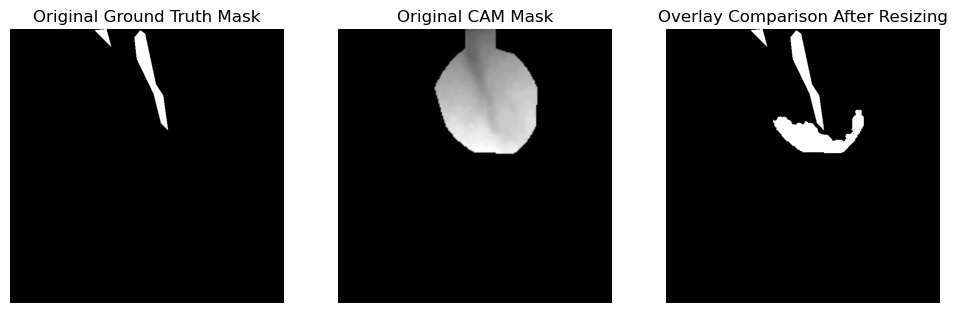

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the masks (update with the new paths)
cam_mask_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg"
real_mask_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png"

cam_mask = cv2.imread(cam_mask_path, cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(real_mask_path, cv2.IMREAD_GRAYSCALE)

# Print original mask shapes to debug
print(f"Original Grad-CAM mask shape: {cam_mask.shape}")
print(f"Original Ground Truth mask shape: {real_mask.shape}")

# Ensure both masks are the same size
if cam_mask.shape != real_mask.shape:
    print("Masks have different sizes. Resizing the cam_mask to match real_mask.")
    cam_mask = cv2.resize(cam_mask, (real_mask.shape[1], real_mask.shape[0]))
    print(f"Resized Grad-CAM mask shape: {cam_mask.shape}")

# Convert masks to binary
_, cam_mask_bin = cv2.threshold(cam_mask, 127, 1, cv2.THRESH_BINARY)
_, real_mask_bin = cv2.threshold(real_mask, 127, 1, cv2.THRESH_BINARY)

# Check if the ground truth mask is fully contained in the Grad-CAM mask
containment = np.all(np.logical_and(real_mask_bin, cam_mask_bin))

# Compute Intersection over Union (IoU)
intersection = np.logical_and(real_mask_bin, cam_mask_bin)
union = np.logical_or(real_mask_bin, cam_mask_bin)
iou_score = np.sum(intersection) / np.sum(union)

# Compute Dice Coefficient
dice_score = 2 * np.sum(intersection) / (np.sum(real_mask_bin) + np.sum(cam_mask_bin))

# Print metrics
print(f"Containment (Ground Truth in Grad-CAM): {'100%' if containment else 'Not 100%'}")
print(f"IoU Score: {iou_score:.4f}")
print(f"Dice Coefficient: {dice_score:.4f}")

# Visualize the masks and check alignment
plt.figure(figsize=(12, 6))

# Plot original masks
plt.subplot(1, 3, 1)
plt.imshow(real_mask, cmap='gray')
plt.title('Original Ground Truth Mask')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam_mask, cmap='gray')
plt.title('Original CAM Mask')
plt.axis('off')

# Overlay comparison after resizing
overlay = np.where(cam_mask_bin > 0, 255, 0).astype(np.uint8)
overlay = cv2.addWeighted(real_mask, 0.5, overlay, 0.5, 0)

plt.subplot(1, 3, 3)
plt.imshow(overlay, cmap='gray')
plt.title('Overlay Comparison After Resizing')
plt.axis('off')

plt.show()


Original Grad-CAM mask shape: (224, 224)
Original Ground Truth mask shape: (640, 640)
Masks have different sizes. Resizing the cam_mask to match real_mask.
Resized Grad-CAM mask shape: (640, 640)
Containment (Ground Truth in Grad-CAM): Not 100%
IoU Score: 0.0000
Dice Coefficient: 0.0000


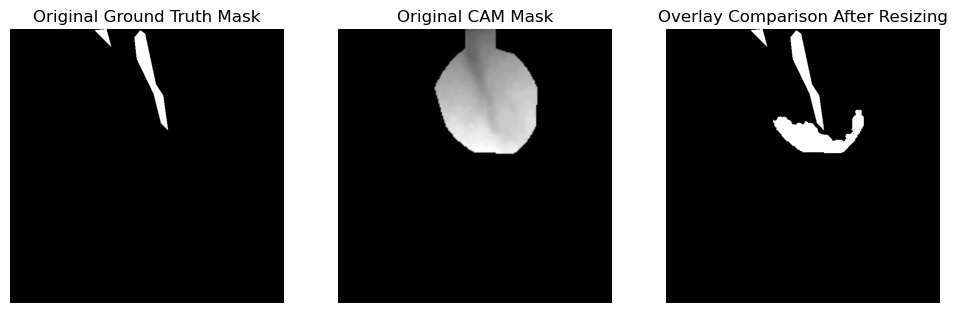

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the masks (update with the new paths)
cam_mask_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg"
real_mask_path = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png"

cam_mask = cv2.imread(cam_mask_path, cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(real_mask_path, cv2.IMREAD_GRAYSCALE)

# Print original mask shapes to debug
print(f"Original Grad-CAM mask shape: {cam_mask.shape}")
print(f"Original Ground Truth mask shape: {real_mask.shape}")

# Ensure both masks are the same size, using a specific interpolation method
if cam_mask.shape != real_mask.shape:
    print("Masks have different sizes. Resizing the cam_mask to match real_mask.")
    # Use INTER_LINEAR or INTER_NEAREST to resize, depending on preference
    cam_mask = cv2.resize(cam_mask, (real_mask.shape[1], real_mask.shape[0]), interpolation=cv2.INTER_LINEAR)
    print(f"Resized Grad-CAM mask shape: {cam_mask.shape}")

# Convert masks to binary
_, cam_mask_bin = cv2.threshold(cam_mask, 127, 1, cv2.THRESH_BINARY)
_, real_mask_bin = cv2.threshold(real_mask, 127, 1, cv2.THRESH_BINARY)

# Check if the ground truth mask is fully contained in the Grad-CAM mask
containment = np.all(np.logical_and(real_mask_bin, cam_mask_bin))

# Compute Intersection over Union (IoU)
intersection = np.logical_and(real_mask_bin, cam_mask_bin)
union = np.logical_or(real_mask_bin, cam_mask_bin)
iou_score = np.sum(intersection) / np.sum(union)

# Compute Dice Coefficient
dice_score = 2 * np.sum(intersection) / (np.sum(real_mask_bin) + np.sum(cam_mask_bin))

# Print metrics
print(f"Containment (Ground Truth in Grad-CAM): {'100%' if containment else 'Not 100%'}")
print(f"IoU Score: {iou_score:.4f}")
print(f"Dice Coefficient: {dice_score:.4f}")

# Visualize the masks and check alignment
plt.figure(figsize=(12, 6))

# Plot original masks
plt.subplot(1, 3, 1)
plt.imshow(real_mask, cmap='gray')
plt.title('Original Ground Truth Mask')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam_mask, cmap='gray')
plt.title('Original CAM Mask')
plt.axis('off')

# Overlay comparison after resizing
overlay = np.where(cam_mask_bin > 0, 255, 0).astype(np.uint8)
overlay = cv2.addWeighted(real_mask, 0.5, overlay, 0.5, 0)

plt.subplot(1, 3, 3)
plt.imshow(overlay, cmap='gray')
plt.title('Overlay Comparison After Resizing')
plt.axis('off')

plt.show()


Dice Score: 0.1651
Intersection over Union (IoU): 0.0900


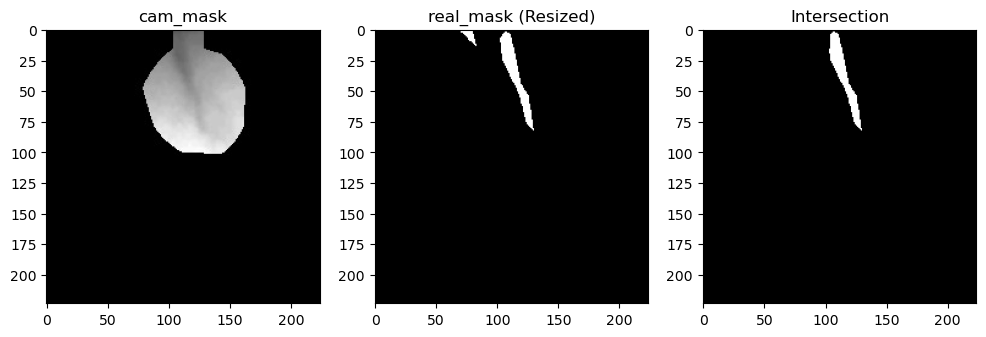

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the images
cam_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg", cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png", cv2.IMREAD_GRAYSCALE)

# Resize real_mask to match the dimensions of cam_mask
real_mask_resized = cv2.resize(real_mask, (cam_mask.shape[1], cam_mask.shape[0]), interpolation=cv2.INTER_NEAREST)

# Binarize the masks
cam_mask_binary = cam_mask > 0
real_mask_binary = real_mask_resized > 0

# Calculate True Positives, False Positives, and False Negatives
TP = np.sum(np.logical_and(cam_mask_binary, real_mask_binary))
FP = np.sum(np.logical_and(cam_mask_binary, np.logical_not(real_mask_binary)))
FN = np.sum(np.logical_and(np.logical_not(cam_mask_binary), real_mask_binary))

# Calculate Dice Score
dice_score = 2 * TP / (2 * TP + FP + FN)

# Calculate Intersection over Union (IoU)
iou = TP / (TP + FP + FN)

print(f"Dice Score: {dice_score:.4f}")
print(f"Intersection over Union (IoU): {iou:.4f}")

# Optionally visualize the masks
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.title('cam_mask')
plt.imshow(cam_mask, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('real_mask (Resized)')
plt.imshow(real_mask_resized, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Intersection')
plt.imshow(np.logical_and(cam_mask_binary, real_mask_binary), cmap='gray')

plt.show()


In [6]:
import numpy as np
import cv2
from scipy.ndimage import center_of_mass

# Load the images
cam_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg", cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png", cv2.IMREAD_GRAYSCALE)

# Resize real_mask to match the dimensions of cam_mask
real_mask_resized = cv2.resize(real_mask, (cam_mask.shape[1], cam_mask.shape[0]))

# Center of Mass Distance
def compute_center_of_mass_distance(pred_mask, gt_mask):
    # Compute centroids for both masks
    pred_com = center_of_mass(pred_mask)
    gt_com = center_of_mass(gt_mask)
    
    # Compute Euclidean distance
    distance = np.sqrt((pred_com[0] - gt_com[0])**2 + (pred_com[1] - gt_com[1])**2)
    return distance

# Weighted Heatmap Intersection
def compute_weighted_intersection(pred_mask, gt_mask):
    # Normalize Grad-CAM heatmap
    pred_norm = pred_mask / np.sum(pred_mask)
    gt_norm = gt_mask / np.sum(gt_mask)
    
    # Compute weighted intersection
    weighted_intersection = np.sum(np.minimum(pred_norm, gt_norm))
    return weighted_intersection

# Region-based Precision and Recall
def compute_region_metrics(pred_mask, gt_mask):
    # Binary masks
    pred_binary = (pred_mask > 0.5).astype(int)
    gt_binary = (gt_mask > 0.5).astype(int)
    
    intersection = np.sum(pred_binary * gt_binary)
    pred_area = np.sum(pred_binary)
    gt_area = np.sum(gt_binary)
    
    # Precision and Recall
    precision = intersection / pred_area if pred_area > 0 else 0
    recall = intersection / gt_area if gt_area > 0 else 0
    
    return precision, recall

# Example usage
distance = compute_center_of_mass_distance(cam_mask, real_mask_resized)
print("Center of Mass Distance:", distance)

weighted_intersection = compute_weighted_intersection(cam_mask, real_mask_resized)
print("Weighted Heatmap Intersection:", weighted_intersection)

precision, recall = compute_region_metrics(cam_mask, real_mask_resized)
print("Precision:", precision)
print("Recall:", recall)


Center of Mass Distance: 29.798100284542137
Weighted Heatmap Intersection: 0.07448664519500946
Precision: 0.09591123271013832
Recall: 0.8504043126684636


In [7]:
import numpy as np
import cv2
from scipy.ndimage import center_of_mass

# Load the images
cam_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg", cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png", cv2.IMREAD_GRAYSCALE)

# Resize real_mask to match the dimensions of cam_mask
real_mask_resized = cv2.resize(real_mask, (cam_mask.shape[1], cam_mask.shape[0]))

# Region-based Recall
def compute_region_recall(pred_mask, gt_mask):
    # Binary masks
    pred_binary = (pred_mask > 0.5).astype(int)
    gt_binary = (gt_mask > 0.5).astype(int)
    
    intersection = np.sum(pred_binary * gt_binary)
    gt_area = np.sum(gt_binary)
    
    # Recall
    recall = intersection / gt_area if gt_area > 0 else 0
    
    return recall

# Example usage for recall only
recall = compute_region_recall(cam_mask, real_mask_resized)
print("Recall:", recall)


Recall: 0.8504043126684636


In [8]:
import os
import numpy as np
import cv2
from scipy.ndimage import center_of_mass

# Directories for Grad-CAM and expert masks
gradcam_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask"
expert_dir = r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked"

# Function to compute recall
def compute_region_recall(pred_mask, gt_mask):
    # Binary masks
    pred_binary = (pred_mask > 0.5).astype(int)
    gt_binary = (gt_mask > 0.5).astype(int)
    
    intersection = np.sum(pred_binary * gt_binary)
    gt_area = np.sum(gt_binary)
    
    # Recall
    recall = intersection / gt_area if gt_area > 0 else 0
    
    return recall

# Iterate over all files in the Grad-CAM directory
recalls = []
for filename in os.listdir(gradcam_dir):
    gradcam_path = os.path.join(gradcam_dir, filename)
    expert_path = os.path.join(expert_dir, filename.replace('.jpg', '_mask.png'))  # Assuming mask has same name with different extension

    # Check if both the Grad-CAM and expert mask files exist
    if os.path.exists(gradcam_path) and os.path.exists(expert_path):
        # Load the images
        cam_mask = cv2.imread(gradcam_path, cv2.IMREAD_GRAYSCALE)
        real_mask = cv2.imread(expert_path, cv2.IMREAD_GRAYSCALE)

        # Resize real_mask to match the dimensions of cam_mask
        real_mask_resized = cv2.resize(real_mask, (cam_mask.shape[1], cam_mask.shape[0]))

        # Compute recall for the current image pair
        recall = compute_region_recall(cam_mask, real_mask_resized)
        recalls.append(recall)
        print(f"Recall for {filename}: {recall}")

# Optionally, you can calculate average recall for the entire dataset
average_recall = np.mean(recalls) if recalls else 0
print(f"Average Recall for the entire dataset: {average_recall}")


Recall for 3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg: 0.8504043126684636
Recall for 3-10-_png.rf.dac42522617fb5b4d8698332965bd375.jpg: 0.612733094744773
Recall for 3-101-_png.rf.c84e23fe771cf1cc8803958b52708f6c.jpg: 0.326632619797892
Recall for 3-102-_png.rf.11be65e9868125a42bd9786a7944ad97.jpg: 0.4223857977917298
Recall for 3-103-_png.rf.425045e1a4967204a4c80fe390205109.jpg: 0.43899261832392533
Recall for 3-105-_png.rf.2cf37fae4c34aaa5d434427a494eb613.jpg: 0.45536630412476914
Recall for 3-106-_png.rf.1e38ee04220711ed993345dd61e1112e.jpg: 0.8352380952380952
Recall for 3-107-_png.rf.909e7014928fbbe5b0cfc19f3b74802f.jpg: 0.9209876543209876
Recall for 3-108-_png.rf.3adc2ac8dc7ac7eb0fb894bba02d507d.jpg: 1.0
Recall for 3-109-_png.rf.e594b1b921e4eebf162a3d7d682451cd.jpg: 0.23325213154689403
Recall for 3-11-_png.rf.83591b92c004d872e17f29efb69b123a.jpg: 0.15876974231088944
Recall for 3-110-_png.rf.e73309b5ea22b7c858ac422736d6e0af.jpg: 0.31481201872263326
Recall for 3-112-_png.rf.f581e0a

Recall: 0.8504043126684636


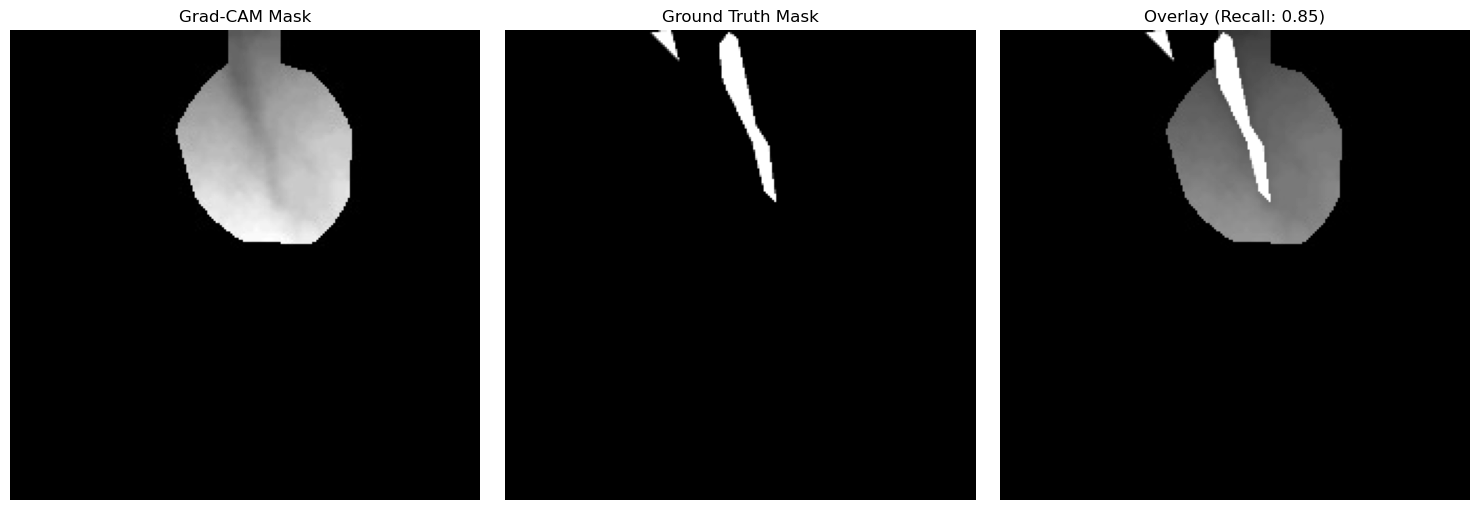

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the images
cam_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg", cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png", cv2.IMREAD_GRAYSCALE)

# Resize real_mask to match the dimensions of cam_mask
real_mask_resized = cv2.resize(real_mask, (cam_mask.shape[1], cam_mask.shape[0]))

# Region-based Recall
def compute_region_recall(pred_mask, gt_mask):
    # Binary masks
    pred_binary = (pred_mask > 0.5).astype(int)
    gt_binary = (gt_mask > 0.5).astype(int)
    
    intersection = np.sum(pred_binary * gt_binary)
    gt_area = np.sum(gt_binary)
    
    # Recall
    recall = intersection / gt_area if gt_area > 0 else 0
    
    return recall

# Compute recall
recall = compute_region_recall(cam_mask, real_mask_resized)
print("Recall:", recall)

# Plotting the images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display Grad-CAM mask
axes[0].imshow(cam_mask, cmap='gray')
axes[0].set_title("Grad-CAM Mask")
axes[0].axis('off')

# Display Ground Truth Mask
axes[1].imshow(real_mask_resized, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')

# Display Overlay of Masks (intersection)
overlay = np.maximum(cam_mask, real_mask_resized)  # Combine both masks for visualization
axes[2].imshow(overlay, cmap='gray')
axes[2].set_title(f"Overlay (Recall: {recall:.2f})")
axes[2].axis('off')

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the images
cam_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\gradcam-mask\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593.jpg", cv2.IMREAD_GRAYSCALE)
real_mask = cv2.imread(r"D:\welding\data\XAI_Metrics\xai_metric.v1i.coco\masked\3-1-_png.rf.72d87e73acd71c4d961a30af5a368593_mask.png", cv2.IMREAD_GRAYSCALE)

# Resize real_mask to match the dimensions of cam_mask
real_mask_resized = cv2.resize(real_mask, (cam_mask.shape[1], cam_mask.shape[0]))

# Region-based Recall
def compute_region_recall(pred_mask, gt_mask):
    # Binary masks
    pred_binary = (pred_mask > 0.5).astype(int)
    gt_binary = (gt_mask > 0.5).astype(int)
    
    intersection = np.sum(pred_binary * gt_binary)
    gt_area = np.sum(gt_binary)
    
    # Recall
    recall = intersection / gt_area if gt_area > 0 else 0
    
    return recall

# Compute recall
recall = compute_region_recall(cam_mask, real_mask_resized)
print("Recall:", recall)

# Plotting the images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display Grad-CAM mask
axes[0].imshow(cam_mask, cmap='gray')
axes[0].set_title("Grad-CAM Mask")
axes[0].axis('off')

# Display Ground Truth Mask
axes[1].imshow(real_mask_resized, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')

# Display Overlay of Masks (intersection)
overlay = np.maximum(cam_mask, real_mask_resized)  # Combine both masks for visualization
axes[2].imshow(overlay, cmap='gray')
axes[2].set_title(f"Overlay (Recall: {recall:.2f})")
axes[2].axis('off')

# Show the plot
plt.tight_layout()
plt.show()
